# 06 — Parametric Study

This notebook repeats the same deterministic pipeline while changing only the load magnitude.
The default sweep uses 50, 100, 150, 200, and 250 N.

## What this notebook does

- Rebuilds the same deterministic geometry for each case.
- Runs the full geometry → mesh → solver → results pipeline repeatedly.
- Aggregates the results into a pandas DataFrame.
- Saves a CSV file and a simple load-vs-response plot.

In [1]:
import json
import logging
import sys
from dataclasses import asdict, is_dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

logging.basicConfig(level=logging.INFO, format='%(levelname)s %(name)s: %(message)s')

def find_module_root(start: Path | None = None) -> Path:
    current = start or Path.cwd()
    for candidate in [current, *current.parents]:
        if (candidate / 'src').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise RuntimeError('Could not locate the fea_cad_one_sample module root.')

def json_safe(value: Any) -> Any:
    if is_dataclass(value):
        return json_safe(asdict(value))
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, dict):
        return {str(key): json_safe(item) for key, item in value.items()}
    if isinstance(value, (list, tuple, set)):
        return [json_safe(item) for item in value]
    return value

def write_json(path: Path, payload: Any) -> Path:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(json_safe(payload), indent=2, sort_keys=True) + '\n', encoding='utf-8')
    return path

def load_json(path: Path) -> dict[str, Any]:
    return json.loads(Path(path).read_text(encoding='utf-8'))

MODULE_ROOT = find_module_root()
if str(MODULE_ROOT) not in sys.path:
    sys.path.insert(0, str(MODULE_ROOT))

import src.interfaces as iface

plt.style.use('seaborn-v0_8-whitegrid')
print(f'[SETUP] MODULE_ROOT={MODULE_ROOT}')

[SETUP] MODULE_ROOT=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample


INFO src.fea_replication.pipeline: build_baseline_config | start | run_dir=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original | source_step_path=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original/original.step | mesh_size_mm=8.0 | load_magnitude_n=50
INFO src.fea_replication.pipeline: build_baseline_config | done | run_dir=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original
INFO src.fea_replication.pipeline: run_parametric_load_study | start | run_dir=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original | load_values_n=[50, 100, 150, 200, 250] |

[STAGE] parametric study: run load sweep
  ccx = /opt/homebrew/Caskroom/miniconda/base/envs/cad_physics/bin/ccx


INFO src.fea_replication.geometry: render_geometry_preview | done | output_path=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original/parametric_study/load_050N/geometry_preview.png
INFO src.fea_replication.geometry: load_geometry_summary | start | step_path=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original/parametric_study/load_050N/cantilever_beam.step | source_mode=provided_step
INFO src.fea_replication.geometry: load_geometry_summary | done | step_path=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original/parametric_study/load_050N/cantilever_beam.step | major_axis=Y | spans_mm=(0.6185900000005435, 0.964536, 0.5357146545280003)
INFO src.fea_replication.g

Info    :  - Label 'Shapes/Open CASCADE STEP translator 7.8 1' (3D)
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 10%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 20%] Meshing curve 5 (Line)
Info    : [ 30%] Meshing curve 6 (Line)
Info    : [ 30%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 40%] Meshing curve 9 (Line)
Info    : [ 50%] Meshing curve 10 (Line)
Info    : [ 50%] Meshing curve 11 (Line)
Info    : [ 60%] Meshing curve 12 (Line)
Info    : [ 60%] Meshing curve 13 (Line)
Info    : [ 70%] Meshing curve 14 (Circle)
Info    : [ 70%] Meshing curve 15 (Line)
Info    : [ 80%] Meshing curve 16 (Line)
Info    : [ 80%] Meshing curve 17 (Line)
Info    : [ 90%] Meshing curve 18 (Line)
Info    : [ 90%] Meshing curve 19 (Line)
Info    : [100%] Meshing curve 20 (Line)
Info    : [100%] Meshing curve 21 (Circle)
Info    : Done meshing 1D (Wall 0.000677208s, CPU 0.

INFO src.fea_replication.geometry: render_geometry_preview | done | output_path=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original/parametric_study/load_100N/geometry_preview.png
INFO src.fea_replication.geometry: load_geometry_summary | start | step_path=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original/parametric_study/load_100N/cantilever_beam.step | source_mode=provided_step
INFO src.fea_replication.geometry: load_geometry_summary | done | step_path=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original/parametric_study/load_100N/cantilever_beam.step | major_axis=Y | spans_mm=(0.6185900000005435, 0.964536, 0.5357146545280003)
INFO src.fea_replication.g

...

Info    :  - Label 'Shapes/Open CASCADE STEP translator 7.8 1' (3D)
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 10%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 20%] Meshing curve 5 (Line)
Info    : [ 30%] Meshing curve 6 (Line)
Info    : [ 30%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 40%] Meshing curve 9 (Line)
Info    : [ 50%] Meshing curve 10 (Line)
Info    : [ 50%] Meshing curve 11 (Line)
Info    : [ 60%] Meshing curve 12 (Line)
Info    : [ 60%] Meshing curve 13 (Line)
Info    : [ 70%] Meshing curve 14 (Circle)
Info    : [ 70%] Meshing curve 15 (Line)
Info    : [ 80%] Meshing curve 16 (Line)
Info    : [ 80%] Meshing curve 17 (Line)
Info    : [ 90%] Meshing curve 18 (Line)
Info    : [ 90%] Meshing curve 19 (Line)
Info    : [100%] Meshing curve 20 (Line)
Info    : [100%] Meshing curve 21 (Circle)
Info    : Done meshing 1D (Wall 0.000454709s, CPU 0.

INFO src.fea_replication.geometry: render_geometry_preview | done | output_path=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original/parametric_study/load_250N/geometry_preview.png
INFO src.fea_replication.geometry: load_geometry_summary | start | step_path=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original/parametric_study/load_250N/cantilever_beam.step | source_mode=provided_step
INFO src.fea_replication.geometry: load_geometry_summary | done | step_path=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original/parametric_study/load_250N/cantilever_beam.step | major_axis=Y | spans_mm=(0.6185900000005435, 0.964536, 0.5357146545280003)
INFO src.fea_replication.g

Info    :  - Label 'Shapes/Open CASCADE STEP translator 7.8 1' (3D)
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 10%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 20%] Meshing curve 5 (Line)
Info    : [ 30%] Meshing curve 6 (Line)
Info    : [ 30%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 40%] Meshing curve 9 (Line)
Info    : [ 50%] Meshing curve 10 (Line)
Info    : [ 50%] Meshing curve 11 (Line)
Info    : [ 60%] Meshing curve 12 (Line)
Info    : [ 60%] Meshing curve 13 (Line)
Info    : [ 70%] Meshing curve 14 (Circle)
Info    : [ 70%] Meshing curve 15 (Line)
Info    : [ 80%] Meshing curve 16 (Line)
Info    : [ 80%] Meshing curve 17 (Line)
Info    : [ 90%] Meshing curve 18 (Line)
Info    : [ 90%] Meshing curve 19 (Line)
Info    : [100%] Meshing curve 20 (Line)
Info    : [100%] Meshing curve 21 (Circle)
Info    : Done meshing 1D (Wall 0.000480167s, CPU 0.

,load_magnitude_n,run_dir,max_displacement_mm,max_von_mises_mpa,estimated_safety_factor,passes_displacement,passes_safety_factor,overall_pass
0,50.0,/Users/vedaangchopra/all_data/complete_technic...,None,None,None,False,None,None
1,100.0,/Users/vedaangchopra/all_data/complete_technic...,None,None,None,False,None,None
2,150.0,/Users/vedaangchopra/all_data/complete_technic...,None,None,None,False,None,None
3,200.0,/Users/vedaangchopra/all_data/complete_technic...,None,None,None,False,None,None
4,250.0,/Users/vedaangchopra/all_data/complete_technic...,None,None,None,False,None,None


  csv_path = /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original/parametric_study_results.csv


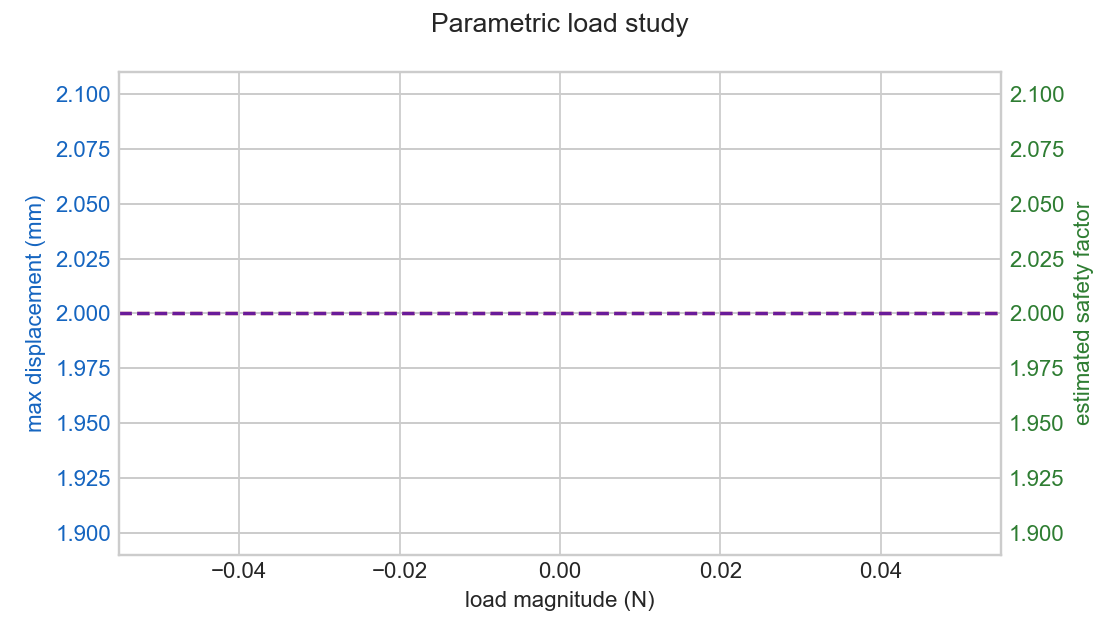

✓ parametric study complete


In [2]:
import shutil

RUN_DIR = MODULE_ROOT / 'outputs' / 'sample_00689964' / '01_dataset_original'
SOURCE_STEP_PATH = RUN_DIR / "original.step" 
MESH_SIZE_MM = 8.0
LOAD_VALUES_N = [50, 100, 150, 200, 250]

print('[STAGE] parametric study: run load sweep')
ccx_path = shutil.which('ccx')
print('  ccx =', ccx_path)
if not ccx_path:
    message = "CalculiX executable 'ccx' was not found on PATH. Install ccx before running the parametric study."
    print(f'ERROR: FileNotFoundError: {message}')
    raise FileNotFoundError(message)

base_config = iface.build_baseline_config(
    run_dir=RUN_DIR,
    source_step_path=SOURCE_STEP_PATH,
    mesh_size_mm=MESH_SIZE_MM,
    load_magnitude_n=LOAD_VALUES_N[0],
)
study_rows = iface.run_parametric_load_study(base_config, LOAD_VALUES_N, force=True)
df = pd.DataFrame(study_rows)
display(df)

csv_path = RUN_DIR / 'parametric_study_results.csv'
df.to_csv(csv_path, index=False)
print('  csv_path =', csv_path)

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(df['load_magnitude_n'], df['max_displacement_mm'], marker='o', color='#1565c0', label='max displacement (mm)')
ax1.set_xlabel('load magnitude (N)')
ax1.set_ylabel('max displacement (mm)', color='#1565c0')
ax1.tick_params(axis='y', labelcolor='#1565c0')
ax1.axhline(base_config.verification_criteria.max_displacement_mm, color='#b71c1c', linestyle='--', label='displacement limit')

ax2 = ax1.twinx()
ax2.plot(df['load_magnitude_n'], df['estimated_safety_factor'], marker='s', color='#2e7d32', label='estimated safety factor')
ax2.set_ylabel('estimated safety factor', color='#2e7d32')
ax2.tick_params(axis='y', labelcolor='#2e7d32')
ax2.axhline(base_config.verification_criteria.required_safety_factor, color='#6a1b9a', linestyle='--', label='safety factor limit')

fig.suptitle('Parametric load study')
fig.tight_layout()
plot_path = RUN_DIR / 'parametric_study_plot.png'
fig.savefig(plot_path, dpi=160)
display(Image(filename=str(plot_path)))
plt.close(fig)

print('✓ parametric study complete')